In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/arbitrage_decisions.csv"
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1785, 41)


,container_id,timestamp,commodity,temperature,humidity,vibration,condition,date,hour,day_of_week,...,commodity_avg_vibration,commodity_warning_count,commodity_anomaly_count,commodity_avg_risk,recommended_action,priority,intervention_required,arbitrage_opportunity,decision_reason,decision_score
0,CONT_001,2026-09-10 17:39:32.831215,Avocado,3.94,71.79,0.29,WARNING,2026-09-10,17,3,...,0.194729,71,53,2.952489,CONTINUE MONITORING,P4,False,False,elevated environmental risk,2
1,CONT_004,2026-09-10 17:39:34.852445,Mango,11.72,88.98,0.12,NORMAL,2026-09-10,17,3,...,0.193234,97,51,2.689362,CONTINUE MONITORING,P4,False,False,elevated environmental risk,2
2,CONT_005,2026-09-10 17:39:36.870612,Tomato,10.18,91.05,0.15,NORMAL,2026-09-10,17,3,...,0.184183,88,39,2.821351,INCREASE MONITORING,P3,False,False,elevated environmental risk,3
3,CONT_005,2026-09-10 17:39:38.890192,Avocado,6.54,85.30,0.17,NORMAL,2026-09-10,17,3,...,0.194729,71,53,2.952489,CONTINUE MONITORING,P4,False,False,elevated environmental risk,2
4,CONT_005,2026-09-10 17:39:40.899424,Tomato,14.06,100.00,0.33,WARNING,2026-09-10,17,3,...,0.184183,88,39,2.821351,CONSIDER REROUTING,P2,True,False,high humidity,6


spoilage_risk
LOW         890
MEDIUM      638
HIGH        222
CRITICAL     35
Name: count, dtype: int64


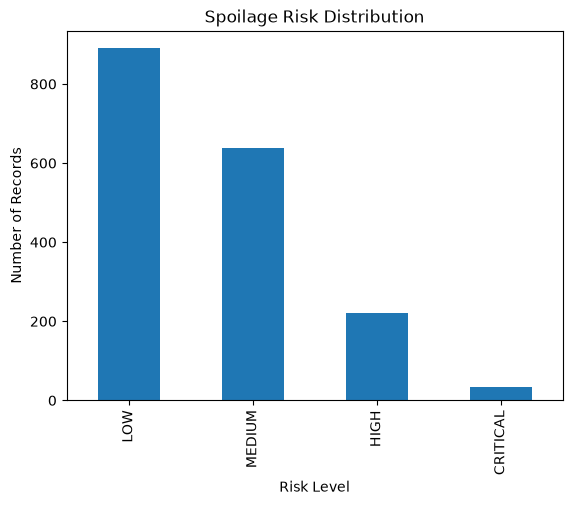

In [2]:
risk_counts = df["spoilage_risk"].value_counts()

print(risk_counts)

risk_counts.plot(
    kind="bar",
    title="Spoilage Risk Distribution"
)

plt.xlabel("Risk Level")
plt.ylabel("Number of Records")
plt.show()

recommended_action
CONTINUE MONITORING    890
INCREASE MONITORING    638
CONSIDER REROUTING     222
URGENT INTERVENTION     35
Name: count, dtype: int64


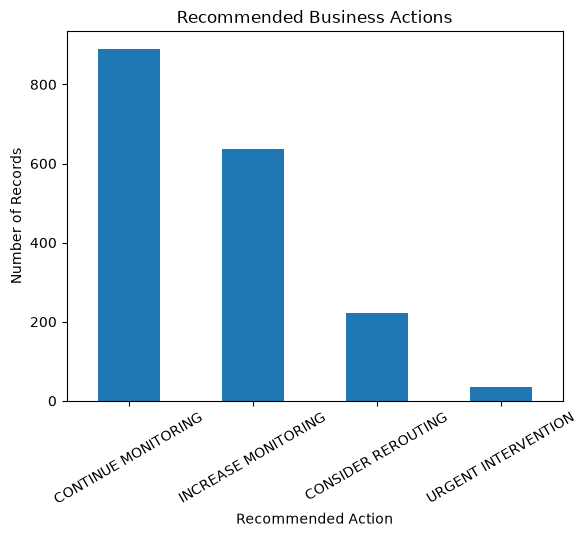

In [3]:
action_counts = df["recommended_action"].value_counts()

print(action_counts)

action_counts.plot(
    kind="bar",
    title="Recommended Business Actions"
)

plt.xlabel("Recommended Action")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.show()

priority
P1     35
P2    222
P3    638
P4    890
Name: count, dtype: int64


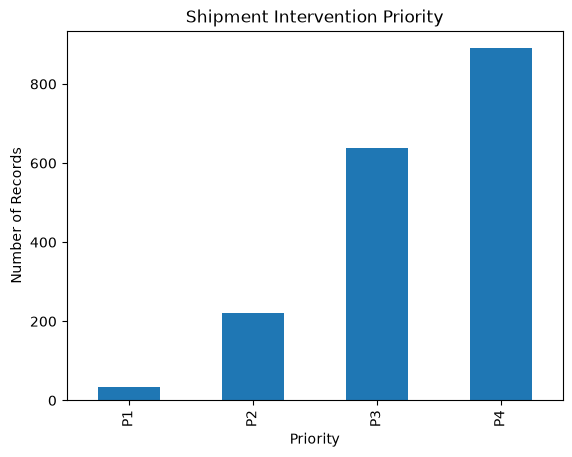

In [4]:
priority_counts = df["priority"].value_counts().sort_index()

print(priority_counts)

priority_counts.plot(
    kind="bar",
    title="Shipment Intervention Priority"
)

plt.xlabel("Priority")
plt.ylabel("Number of Records")
plt.show()

In [5]:
commodity_action = pd.crosstab(
    df["commodity"],
    df["recommended_action"]
)

commodity_action

recommended_action,CONSIDER REROUTING,CONTINUE MONITORING,INCREASE MONITORING,URGENT INTERVENTION
commodity,,,,
Avocado,41,185,202,14
Banana,67,142,199,6
Mango,68,353,40,9
Tomato,46,210,197,6


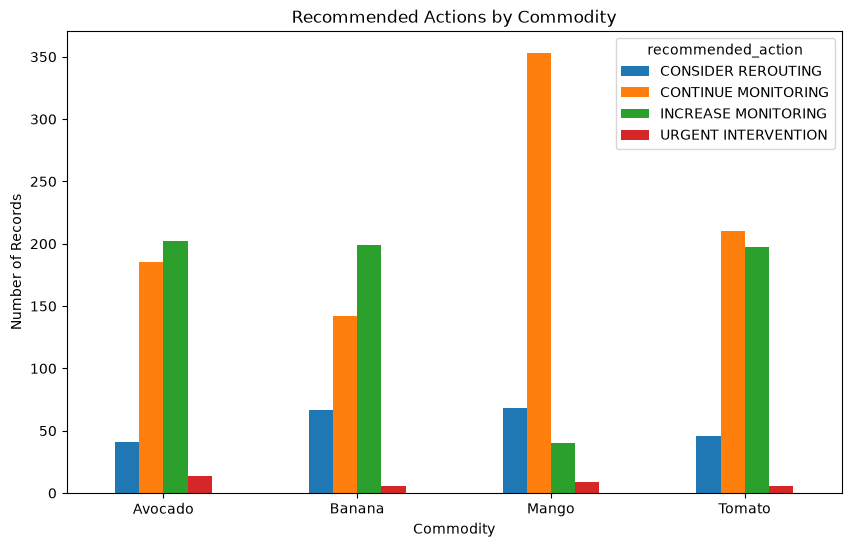

In [6]:
commodity_action.plot(
    kind="bar",
    figsize=(10, 6),
    title="Recommended Actions by Commodity"
)

plt.xlabel("Commodity")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [7]:
container_action = pd.crosstab(
    df["container_id"],
    df["recommended_action"]
)

container_action

recommended_action,CONSIDER REROUTING,CONTINUE MONITORING,INCREASE MONITORING,URGENT INTERVENTION
container_id,,,,
CONT_001,38,170,124,8
CONT_002,43,173,115,8
CONT_003,52,180,129,8
CONT_004,51,181,126,5
CONT_005,38,186,144,6


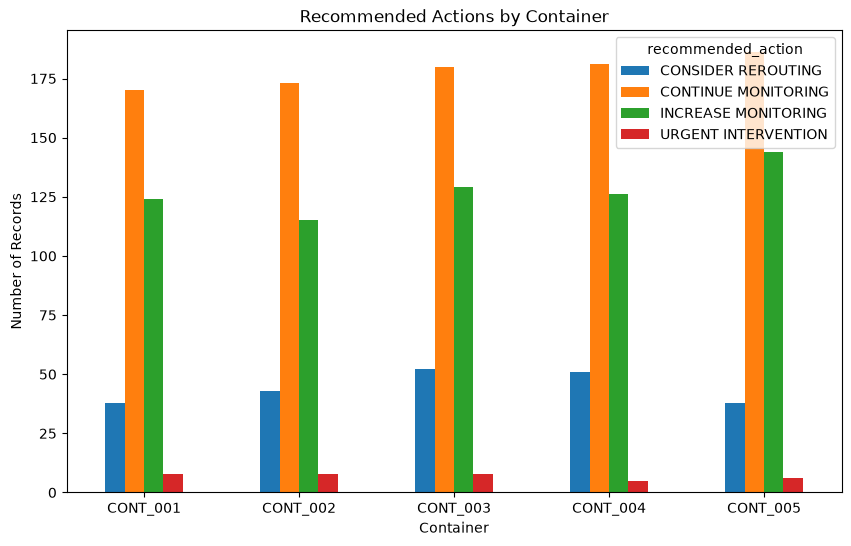

In [8]:
container_action.plot(
    kind="bar",
    figsize=(10, 6),
    title="Recommended Actions by Container"
)

plt.xlabel("Container")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [10]:
critical_records = df[
    df["spoilage_risk"] == "CRITICAL"
].copy()

critical_records = critical_records.sort_values(
    "decision_score",
    ascending=False
)

critical_records[
    [
        "container_id",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "condition",
        "environmental_risk_score",
        "decision_score",
        "recommended_action",
        "priority",
        "decision_reason"
    ]
].head(20)

,container_id,commodity,temperature,humidity,vibration,condition,environmental_risk_score,decision_score,recommended_action,priority,decision_reason
511,CONT_001,Banana,20.45,100.0,0.41,ANOMALY,8,12,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
122,CONT_003,Avocado,16.12,100.0,0.46,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
80,CONT_004,Avocado,16.14,100.0,0.45,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
167,CONT_001,Banana,18.97,100.0,0.45,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
168,CONT_005,Avocado,18.85,100.0,0.41,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
300,CONT_004,Avocado,19.79,100.0,0.47,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
287,CONT_003,Tomato,16.06,100.0,0.49,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
329,CONT_001,Mango,19.45,100.0,0.48,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
355,CONT_003,Tomato,18.02,100.0,0.47,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
627,CONT_001,Avocado,19.96,100.0,0.52,ANOMALY,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."


In [11]:
critical_records.sort_values("decision_score")

,container_id,timestamp,commodity,temperature,humidity,vibration,condition,date,hour,day_of_week,...,commodity_avg_vibration,commodity_warning_count,commodity_anomaly_count,commodity_avg_risk,recommended_action,priority,intervention_required,arbitrage_opportunity,decision_reason,decision_score
122,CONT_003,2026-09-10 17:41:46.683242,Avocado,16.12,100.0,0.46,ANOMALY,2026-09-10,17,3,...,0.194729,71,53,2.952489,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
80,CONT_004,2026-09-10 17:41:04.307125,Avocado,16.14,100.0,0.45,ANOMALY,2026-09-10,17,3,...,0.194729,71,53,2.952489,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
167,CONT_001,2026-09-10 17:42:31.276598,Banana,18.97,100.0,0.45,ANOMALY,2026-09-10,17,3,...,0.192995,96,41,3.159420,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
168,CONT_005,2026-09-10 17:42:33.281371,Avocado,18.85,100.0,0.41,ANOMALY,2026-09-10,17,3,...,0.194729,71,53,2.952489,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
287,CONT_003,2026-09-10 17:44:33.554597,Tomato,16.06,100.0,0.49,ANOMALY,2026-09-10,17,3,...,0.184183,88,39,2.821351,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
300,CONT_004,2026-09-10 17:44:47.431392,Avocado,19.79,100.0,0.47,ANOMALY,2026-09-10,17,3,...,0.194729,71,53,2.952489,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
329,CONT_001,2026-09-10 17:46:11.211941,Mango,19.45,100.0,0.48,ANOMALY,2026-09-10,17,3,...,0.193234,97,51,2.689362,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
355,CONT_003,2026-09-10 17:46:37.755725,Tomato,18.02,100.0,0.47,ANOMALY,2026-09-10,17,3,...,0.184183,88,39,2.821351,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
723,CONT_002,2026-09-10 17:59:04.450639,Tomato,16.04,100.0,0.60,ANOMALY,2026-09-10,17,3,...,0.184183,88,39,2.821351,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11
627,CONT_001,2026-09-10 17:55:47.691495,Avocado,19.96,100.0,0.52,ANOMALY,2026-09-10,17,3,...,0.194729,71,53,2.952489,URGENT INTERVENTION,P1,True,True,"high temperature, high humidity, elevated vibr...",11


In [12]:
df["decision_score"]

0       2
1       2
2       3
3       2
4       6
       ..
1780    5
1781    2
1782    6
1783    3
1784    2
Name: decision_score, Length: 1785, dtype: int64

In [13]:
print(df["decision_score"].head())
print(df["decision_score"].min())
print(df["decision_score"].max())

0    2
1    2
2    3
3    2
4    6
Name: decision_score, dtype: int64
0
12


In [14]:
arbitrage = df[
    df["arbitrage_opportunity"] == True
].copy()

print("Potential arbitrage opportunities:", len(arbitrage))

arbitrage = arbitrage.sort_values(
    "decision_score",
    ascending=False
)

arbitrage[
    [
        "container_id",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "spoilage_risk",
        "environmental_risk_score",
        "decision_score",
        "recommended_action",
        "priority",
        "decision_reason"
    ]
].head(20)

Potential arbitrage opportunities: 107


,container_id,commodity,temperature,humidity,vibration,spoilage_risk,environmental_risk_score,decision_score,recommended_action,priority,decision_reason
511,CONT_001,Banana,20.45,100.0,0.41,CRITICAL,8,12,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
122,CONT_003,Avocado,16.12,100.0,0.46,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
80,CONT_004,Avocado,16.14,100.0,0.45,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
300,CONT_004,Avocado,19.79,100.0,0.47,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
627,CONT_001,Avocado,19.96,100.0,0.52,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
355,CONT_003,Tomato,18.02,100.0,0.47,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
329,CONT_001,Mango,19.45,100.0,0.48,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
168,CONT_005,Avocado,18.85,100.0,0.41,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
287,CONT_003,Tomato,16.06,100.0,0.49,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
167,CONT_001,Banana,18.97,100.0,0.45,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."


In [16]:
arbitrage = df[
    df["arbitrage_opportunity"] == True
].copy()

print("Potential arbitrage opportunities:", len(arbitrage))

arbitrage = arbitrage.sort_values(
    "decision_score",
    ascending=False
)

arbitrage[
    [
        "container_id",
        "commodity",
        "temperature",
        "humidity",
        "vibration",
        "spoilage_risk",
        "environmental_risk_score",
        "decision_score",
        "recommended_action",
        "priority",
        "decision_reason"
    ]
].head(20)

Potential arbitrage opportunities: 107


,container_id,commodity,temperature,humidity,vibration,spoilage_risk,environmental_risk_score,decision_score,recommended_action,priority,decision_reason
511,CONT_001,Banana,20.45,100.0,0.41,CRITICAL,8,12,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
122,CONT_003,Avocado,16.12,100.0,0.46,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
80,CONT_004,Avocado,16.14,100.0,0.45,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
300,CONT_004,Avocado,19.79,100.0,0.47,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
627,CONT_001,Avocado,19.96,100.0,0.52,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
355,CONT_003,Tomato,18.02,100.0,0.47,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
329,CONT_001,Mango,19.45,100.0,0.48,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
168,CONT_005,Avocado,18.85,100.0,0.41,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
287,CONT_003,Tomato,16.06,100.0,0.49,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."
167,CONT_001,Banana,18.97,100.0,0.45,CRITICAL,7,11,URGENT INTERVENTION,P1,"high temperature, high humidity, elevated vibr..."


In [17]:
total_records = len(df)
arbitrage_records = len(arbitrage)

arbitrage_percentage = (
    arbitrage_records / total_records
) * 100

print("Total records:", total_records)
print("Potential arbitrage records:", arbitrage_records)
print("Potential arbitrage percentage:", round(arbitrage_percentage, 2), "%")

Total records: 1785
Potential arbitrage records: 107
Potential arbitrage percentage: 5.99 %


In [18]:
commodity_arbitrage = (
    arbitrage.groupby("commodity")
    .size()
    .sort_values(ascending=False)
)

print(commodity_arbitrage)

commodity
Banana     37
Mango      33
Avocado    29
Tomato      8
dtype: int64


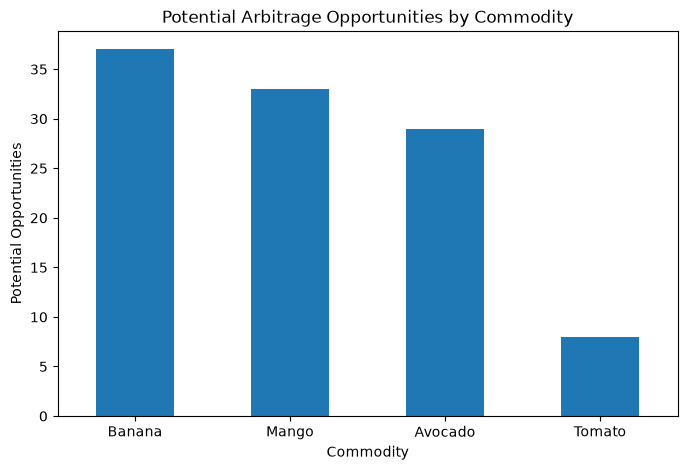

In [19]:
commodity_arbitrage.plot(
    kind="bar",
    figsize=(8, 5),
    title="Potential Arbitrage Opportunities by Commodity"
)

plt.xlabel("Commodity")
plt.ylabel("Potential Opportunities")
plt.xticks(rotation=0)
plt.show()

In [20]:
container_arbitrage = (
    arbitrage.groupby("container_id")
    .size()
    .sort_values(ascending=False)
)

print(container_arbitrage)

container_id
CONT_001    25
CONT_004    24
CONT_002    20
CONT_003    19
CONT_005    19
dtype: int64


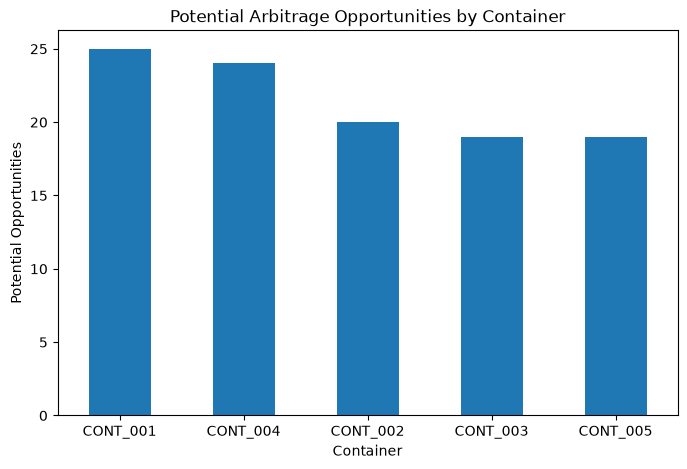

In [21]:
container_arbitrage.plot(
    kind="bar",
    figsize=(8, 5),
    title="Potential Arbitrage Opportunities by Container"
)

plt.xlabel("Container")
plt.ylabel("Potential Opportunities")
plt.xticks(rotation=0)
plt.show()

In [22]:
reason_counts = (
    arbitrage["decision_reason"]
    .value_counts()
)

print(reason_counts)

decision_reason
high temperature, high humidity, elevated vibration, sensor anomaly    48
high temperature, high humidity                                        41
high humidity, elevated vibration, sensor anomaly                      16
high temperature, high humidity, elevated vibration                     2
Name: count, dtype: int64


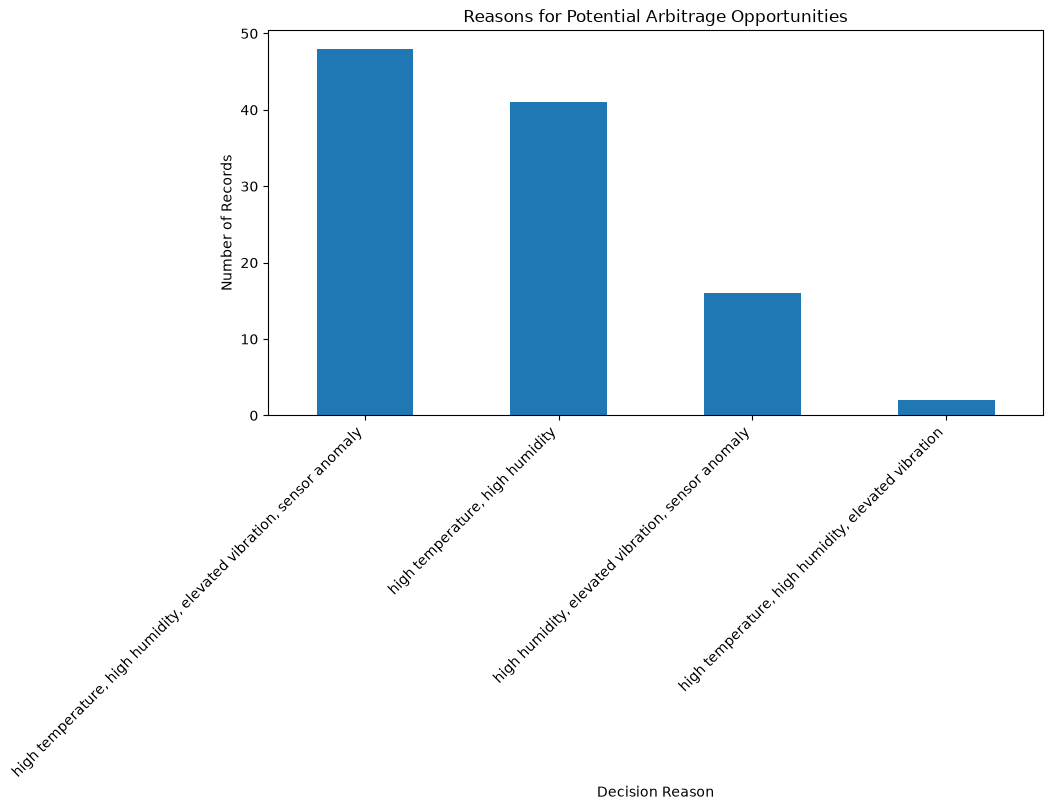

In [23]:
reason_counts.plot(
    kind="bar",
    figsize=(10, 5),
    title="Reasons for Potential Arbitrage Opportunities"
)

plt.xlabel("Decision Reason")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.show()

In [24]:
business_summary = pd.DataFrame({
    "Metric": [
        "Total Telemetry Records",
        "HIGH Risk Records",
        "CRITICAL Risk Records",
        "Potential Arbitrage Records",
        "Intervention Required Records"
    ],
    "Value": [
        len(df),
        (df["spoilage_risk"] == "HIGH").sum(),
        (df["spoilage_risk"] == "CRITICAL").sum(),
        df["arbitrage_opportunity"].sum(),
        df["intervention_required"].sum()
    ]
})

business_summary

,Metric,Value
0,Total Telemetry Records,1785
1,HIGH Risk Records,222
2,CRITICAL Risk Records,35
3,Potential Arbitrage Records,107
4,Intervention Required Records,257


In [25]:
print("Total:", len(df))
print("Arbitrage:", df["arbitrage_opportunity"].sum())
print(df["recommended_action"].value_counts())


Total: 1785
Arbitrage: 107
recommended_action
CONTINUE MONITORING    890
INCREASE MONITORING    638
CONSIDER REROUTING     222
URGENT INTERVENTION     35
Name: count, dtype: int64


In [26]:
business_summary = pd.DataFrame({
    "Metric": [
        "Total Telemetry Records",
        "HIGH Risk Records",
        "CRITICAL Risk Records",
        "Potential Arbitrage Records",
        "Intervention Required Records"
    ],
    "Value": [
        len(df),
        (df["spoilage_risk"] == "HIGH").sum(),
        (df["spoilage_risk"] == "CRITICAL").sum(),
        df["arbitrage_opportunity"].sum(),
        df["intervention_required"].sum()
    ]
})

business_summary

,Metric,Value
0,Total Telemetry Records,1785
1,HIGH Risk Records,222
2,CRITICAL Risk Records,35
3,Potential Arbitrage Records,107
4,Intervention Required Records,257


In [27]:
total = len(df)

print("HIGH risk %:",
      round((df["spoilage_risk"] == "HIGH").sum() / total * 100, 2))

print("CRITICAL risk %:",
      round((df["spoilage_risk"] == "CRITICAL").sum() / total * 100, 2))

print("Intervention required %:",
      round(df["intervention_required"].sum() / total * 100, 2))

print("Arbitrage opportunity %:",
      round(df["arbitrage_opportunity"].sum() / total * 100, 2))

HIGH risk %: 12.44
CRITICAL risk %: 1.96
Intervention required %: 14.4
Arbitrage opportunity %: 5.99
